## Feature Engineering

Buscaremos convertir a log odds y modelar el comportamiento de cada feature vs su log_odds

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pandas.api.types import is_numeric_dtype, is_string_dtype, is_datetime64_any_dtype
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

PARENT_DIRECTORY_1 = Path.cwd().parent.parent.parent
sys.path.append(f"{str(PARENT_DIRECTORY_1)}")

from EDA.utils.classifications import EDAClasificacion
from Feature_Engineering.utils.transformers.woe import WOEClassic, Logit_Smoothing_Rolling
from Feature_Engineering.utils.selection.gini import gini_rule_selection
from Feature_Engineering.utils.selection.correlation import correlation
from Feature_Engineering.utils.selection.vif import vif
from Feature_Engineering.utils.selection.psi import dataframe_psi
from Feature_Engineering.utils.transformers.binning import Binning
from Feature_Engineering.utils.selection.iv import information_value

from Feature_Engineering.utils.transformers.outliers import AutoOutlierHandler
from Feature_Engineering.utils.selection.feature_selector import FeatureSelector


In [2]:
df_train = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
df_test = pd.read_csv('../data/raw/cs-test.csv', index_col=0)

TARGET = 'SeriousDlqin2yrs'
FEATS_NUMERICAS = [c for c in df_train.columns.tolist() if c != TARGET]

In [3]:
df_train.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

#### Tratamiento de Outliers

In [4]:
Tratamiento_Outliers = AutoOutlierHandler(method='percentile', 
                                          return_dataframe = True, 
                                          exclude_continuous= False,
                                          strategy= 'windsorization')

X_transformed_outliers = Tratamiento_Outliers.fit(df_train[FEATS_NUMERICAS])
x_trans_train = X_transformed_outliers.transform(X= df_train[FEATS_NUMERICAS])

In [5]:
x_trans_train

,MonthlyIncome,NumberOfDependents,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,RevolvingUtilizationOfUnsecuredLines,DebtRatio
1,9120.0,2.0,45,2,13,0,4,0,0.766127,0.802982
2,2600.0,1.0,40,0,4,0,0,0,0.957151,0.121876
3,3042.0,0.0,38,1,2,1,0,0,0.658180,0.085113
4,3300.0,0.0,30,0,5,0,0,0,0.233810,0.036050
5,25000.0,0.0,49,1,7,0,1,0,0.907239,0.024926
...,...,...,...,...,...,...,...,...,...,...
149996,2100.0,0.0,74,0,4,0,1,0,0.040674,0.225131
149997,5584.0,2.0,44,0,4,0,1,0,0.299745,0.716562
149998,NaN,0.0,58,0,18,0,1,0,0.246044,3870.000000
149999,5716.0,0.0,30,0,4,0,0,0,0.000000,0.000000


#### Smoothing Log-odds Rolling

In [6]:
x_trans_train.columns

Index(['MonthlyIncome', 'NumberOfDependents', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio'],
      dtype='object')

In [7]:
df_train.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

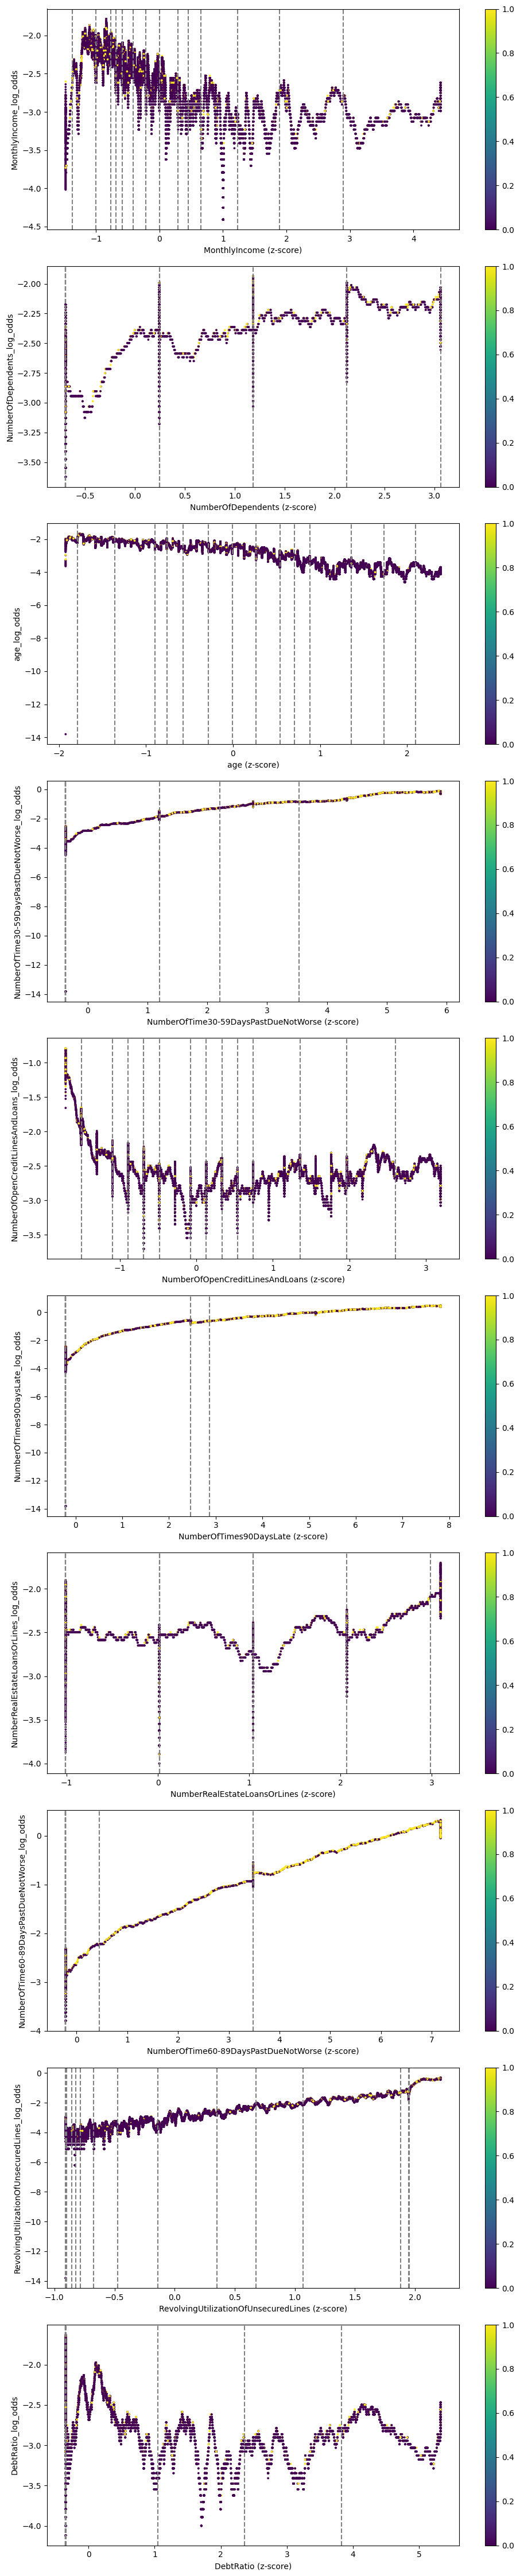

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,feat,function,auc_score_train,auc_score_val,r2_score
0,MonthlyIncome,logarithmic,0.574984,0.578731,0.020552
1,NumberOfDependents,polynomial_1,0.545507,0.549962,0.418343
2,age,polynomial_1,0.630955,0.645652,0.820277
3,NumberOfTime30-59DaysPastDueNotWorse,polynomial_1,0.686970,0.695416,0.787866
4,NumberOfOpenCreditLinesAndLoans,polynomial_1,0.546330,0.539902,0.077480
5,NumberOfTimes90DaysLate,polynomial_1,0.659081,0.652470,0.766860
6,NumberRealEstateLoansOrLines,polynomial_1,0.536094,0.540528,0.078617
7,NumberOfTime60-89DaysPastDueNotWorse,polynomial_1,0.622201,0.620665,0.824595
8,RevolvingUtilizationOfUnsecuredLines,polynomial_1,0.777888,0.777486,0.887166
9,DebtRatio,polynomial_1,0.477167,0.473647,0.060358


,return_dataframe,True
,show_details,True


In [8]:
Feature_Engineering = Logit_Smoothing_Rolling(return_dataframe=True, show_details=True)
Feature_Engineering.fit(x_trans_train, df_train['SeriousDlqin2yrs'])

In [9]:
X_train_transformed_log_odds = Feature_Engineering.transform(
    X= df_train[FEATS_NUMERICAS]
)

'==== Estas visualizando el DataFrame Comparativo ====='

,feature,auc_score_train,auc_score_val,auc_score_test
0,MonthlyIncome,0.574984,0.578731,NaN
1,NumberOfDependents,0.545507,0.549962,NaN
2,age,0.630955,0.645652,NaN
3,NumberOfTime30-59DaysPastDueNotWorse,0.686970,0.695416,NaN
4,NumberOfOpenCreditLinesAndLoans,0.546330,0.539902,NaN
5,NumberOfTimes90DaysLate,0.659081,0.652470,NaN
6,NumberRealEstateLoansOrLines,0.536094,0.540528,NaN
7,NumberOfTime60-89DaysPastDueNotWorse,0.622201,0.620665,NaN
8,RevolvingUtilizationOfUnsecuredLines,0.777888,0.777486,NaN
9,DebtRatio,0.477167,0.473647,NaN


In [10]:
X_train_transformed_log_odds

,MonthlyIncome_log_odds,NumberOfDependents_log_odds,age_log_odds,NumberOfTime30-59DaysPastDueNotWorse_log_odds,NumberOfOpenCreditLinesAndLoans_log_odds,NumberOfTimes90DaysLate_log_odds,NumberRealEstateLoansOrLines_log_odds,NumberOfTime60-89DaysPastDueNotWorse_log_odds,RevolvingUtilizationOfUnsecuredLines_log_odds,DebtRatio_log_odds
1,-2.684272,-2.454202,-2.505694,-1.142581,-2.774852,-3.035551,-3.123508,-2.93999,-1.861899,-2.665558
2,-2.630476,-2.613971,-2.323920,-3.160649,-2.602290,-3.035551,-2.591965,-2.93999,-1.302836,-2.665486
3,-2.637205,-2.773741,-2.251210,-2.151615,-2.563942,-1.482066,-2.591965,-2.93999,-2.177822,-2.665482
4,-2.640694,-2.773741,-1.960372,-3.160649,-2.621463,-3.035551,-2.591965,-2.93999,-3.419809,-2.665477
5,-2.767532,-2.773741,-2.651113,-2.151615,-2.659810,-3.035551,-2.680556,-2.93999,-1.448910,-2.665476
...,...,...,...,...,...,...,...,...,...,...
149996,-2.621322,-2.773741,-3.559982,-3.160649,-2.602290,-3.035551,-2.680556,-2.93999,-3.985052,-2.665497
149997,-2.663241,-2.454202,-2.469339,-3.160649,-2.602290,-3.035551,-2.680556,-2.93999,-3.226839,-2.665549
149998,-2.847353,-2.773741,-2.978306,-3.160649,-2.870719,-3.035551,-2.680556,-2.93999,-3.384004,-3.074593
149999,-2.664243,-2.773741,-1.960372,-3.160649,-2.602290,-3.035551,-2.591965,-2.93999,-4.104091,-2.665473


#### Feature Selection

Regla de Negocio

In [11]:
df_gini_selection_crudas = gini_rule_selection(
    X= df_train[FEATS_NUMERICAS],
    y_true= df_train[TARGET]
)
df_gini_selection_crudas

,feature,roc_auc,gini,missing_pct,regla
0,RevolvingUtilizationOfUnsecuredLines,0.778,0.556,0.000000,Mantener
2,NumberOfTime30-59DaysPastDueNotWorse,0.690,0.379,0.000000,Mantener
6,NumberOfTimes90DaysLate,0.657,0.314,0.000000,Mantener
8,NumberOfTime60-89DaysPastDueNotWorse,0.622,0.243,0.000000,Mantener
9,NumberOfDependents,0.547,0.094,0.026160,Mantener
3,DebtRatio,0.524,0.048,0.000000,Mantener
7,NumberRealEstateLoansOrLines,0.463,-0.075,0.000000,Revisar
5,NumberOfOpenCreditLinesAndLoans,0.455,-0.089,0.000000,Revisar
4,MonthlyIncome,0.424,-0.152,0.198207,Eliminar
1,age,0.365,-0.271,0.000000,Revisar


In [12]:
df_gini_selection_transformadas = gini_rule_selection(
    X= X_train_transformed_log_odds,
    y_true= df_train[TARGET]
)
df_gini_selection_transformadas

,feature,roc_auc,gini,missing_pct,regla
8,RevolvingUtilizationOfUnsecuredLines_log_odds,0.778,0.556,0.0,Mantener
3,NumberOfTime30-59DaysPastDueNotWorse_log_odds,0.690,0.379,0.0,Mantener
5,NumberOfTimes90DaysLate_log_odds,0.657,0.314,0.0,Mantener
2,age_log_odds,0.635,0.271,0.0,Mantener
7,NumberOfTime60-89DaysPastDueNotWorse_log_odds,0.622,0.243,0.0,Mantener
0,MonthlyIncome_log_odds,0.568,0.135,0.0,Mantener
1,NumberOfDependents_log_odds,0.549,0.098,0.0,Mantener
4,NumberOfOpenCreditLinesAndLoans_log_odds,0.545,0.089,0.0,Mantener
6,NumberRealEstateLoansOrLines_log_odds,0.537,0.075,0.0,Mantener
9,DebtRatio_log_odds,0.476,-0.048,0.0,Revisar


Correlaciones

In [13]:
df_corr_X_transformed = correlation(X= X_train_transformed_log_odds, method= 'pearson')
df_corr_X_transformed

,Features,Correlación
36,NumberOfTimes90DaysLate_log_odds_NumberOfTime6...,0.9928
27,NumberOfTime30-59DaysPastDueNotWorse_log_odds_...,0.9870
25,NumberOfTime30-59DaysPastDueNotWorse_log_odds_...,0.9836
31,NumberOfOpenCreditLinesAndLoans_log_odds_Numbe...,0.4340
8,MonthlyIncome_log_odds_DebtRatio_log_odds,0.2288
9,NumberOfDependents_log_odds_age_log_odds,0.2210
0,MonthlyIncome_log_odds_NumberOfDependents_log_...,0.2123
1,MonthlyIncome_log_odds_age_log_odds,0.1593
18,age_log_odds_NumberOfOpenCreditLinesAndLoans_l...,0.1477
41,NumberRealEstateLoansOrLines_log_odds_DebtRati...,0.1200


In [14]:
alta_correlacion = [
    'NumberOfTimes90DaysLate (Gini: 0.314)',
    'NumberOfTime60-89DaysPastDueNotWorse (Gini: 0.243)',

    'NumberOfTime30-59DaysPastDueNotWorse (Gini: 0.379)',
    'NumberOfTime60-89DaysPastDueNotWorse (Gini: 0.243)'

]
print('''Se repite la feature "NumberOfTime60-89DaysPastDueNotWorse", 
por lo que es tentativa a eliminar
''')
for i in alta_correlacion:
    print(i)

Se repite la feature "NumberOfTime60-89DaysPastDueNotWorse", 
por lo que es tentativa a eliminar

NumberOfTimes90DaysLate (Gini: 0.314)
NumberOfTime60-89DaysPastDueNotWorse (Gini: 0.243)
NumberOfTime30-59DaysPastDueNotWorse (Gini: 0.379)
NumberOfTime60-89DaysPastDueNotWorse (Gini: 0.243)


VIF

In [15]:
df_vif_X_transformado = vif(X= X_train_transformed_log_odds)
df_vif_X_transformado

,feature,VIF
7,NumberOfTime60-89DaysPastDueNotWorse_log_odds,91.341056
5,NumberOfTimes90DaysLate_log_odds,73.101277
3,NumberOfTime30-59DaysPastDueNotWorse_log_odds,40.870425
4,NumberOfOpenCreditLinesAndLoans_log_odds,1.290573
6,NumberRealEstateLoansOrLines_log_odds,1.269968
1,NumberOfDependents_log_odds,1.125960
0,MonthlyIncome_log_odds,1.122504
2,age_log_odds,1.106412
9,DebtRatio_log_odds,1.070141
8,RevolvingUtilizationOfUnsecuredLines_log_odds,1.000334


PSI

In [16]:
df_psi_feats_crudas = dataframe_psi(train_df= df_train[FEATS_NUMERICAS], test_df= df_test[FEATS_NUMERICAS])
df_psi_feats_crudas

,feature,type,psi,interpretacion
0,MonthlyIncome,numeric,0.0004,Sin drift
1,RevolvingUtilizationOfUnsecuredLines,numeric,0.0001,Sin drift
2,age,numeric,0.0001,Sin drift
3,DebtRatio,numeric,0.0001,Sin drift
4,NumberOfOpenCreditLinesAndLoans,numeric,0.0001,Sin drift
5,NumberRealEstateLoansOrLines,numeric,0.0001,Sin drift
6,NumberOfDependents,numeric,0.0001,Sin drift
7,NumberOfTime30-59DaysPastDueNotWorse,numeric,0.0000,Sin drift
8,NumberOfTimes90DaysLate,numeric,0.0000,Sin drift
9,NumberOfTime60-89DaysPastDueNotWorse,numeric,0.0000,Sin drift


Information Value

In [17]:
information_value_X_raw = Binning(strategy='width', show_dataframe = True)
information_value_X_raw.fit(X= df_train[FEATS_NUMERICAS])
df_iv = information_value_X_raw.transform(X= df_train[FEATS_NUMERICAS], y= df_train[TARGET], operation= 'iv')
df_iv

,feature,iv
1,age,0.2528
6,NumberOfTimes90DaysLate,0.0423
2,NumberOfTime30-59DaysPastDueNotWorse,0.0409
8,NumberOfTime60-89DaysPastDueNotWorse,0.0392
5,NumberOfOpenCreditLinesAndLoans,0.0388
9,NumberOfDependents,0.0176
7,NumberRealEstateLoansOrLines,0.0108
4,MonthlyIncome,0.0079
0,RevolvingUtilizationOfUnsecuredLines,0.0002
3,DebtRatio,0.0001


Se procederá a eliminar la feature: 'NumberOfTime60-89DaysPastDueNotWorse_log_odds' y validar el VIF posterior a eso y sus correlaciones

In [18]:
FEATS_NUMERICAS_NEW = [col for col in X_train_transformed_log_odds.columns.tolist() if col != 'NumberOfTime60-89DaysPastDueNotWorse_log_odds']

df_corr_X_transformed = correlation(X= X_train_transformed_log_odds[FEATS_NUMERICAS_NEW], method= 'pearson')
display(df_corr_X_transformed)
df_vif_X_transformado_drop = vif(X= X_train_transformed_log_odds[FEATS_NUMERICAS_NEW])
display(df_vif_X_transformado_drop)

,Features,Correlación
22,NumberOfTime30-59DaysPastDueNotWorse_log_odds_...,0.9836
27,NumberOfOpenCreditLinesAndLoans_log_odds_Numbe...,0.4340
7,MonthlyIncome_log_odds_DebtRatio_log_odds,0.2288
8,NumberOfDependents_log_odds_age_log_odds,0.2210
0,MonthlyIncome_log_odds_NumberOfDependents_log_...,0.2123
1,MonthlyIncome_log_odds_age_log_odds,0.1593
16,age_log_odds_NumberOfOpenCreditLinesAndLoans_l...,0.1477
34,NumberRealEstateLoansOrLines_log_odds_DebtRati...,0.1200
26,NumberOfOpenCreditLinesAndLoans_log_odds_Numbe...,0.0800
15,age_log_odds_NumberOfTime30-59DaysPastDueNotWo...,0.0630


,feature,VIF
5,NumberOfTimes90DaysLate_log_odds,31.439615
3,NumberOfTime30-59DaysPastDueNotWorse_log_odds,31.343410
4,NumberOfOpenCreditLinesAndLoans_log_odds,1.290571
6,NumberRealEstateLoansOrLines_log_odds,1.269904
1,NumberOfDependents_log_odds,1.125391
0,MonthlyIncome_log_odds,1.122493
2,age_log_odds,1.105138
8,DebtRatio_log_odds,1.070136
7,RevolvingUtilizationOfUnsecuredLines_log_odds,1.000333


In [19]:
df_corr_X_transformed.iloc[0,0]

'NumberOfTime30-59DaysPastDueNotWorse_log_odds_NumberOfTimes90DaysLate_log_odds'

Nuevas variables con alta correlación:
- NumberOfTime30-59DaysPastDueNotWorse_log_odds (Gini: 0.379)
- NumberOfTimes90DaysLate_log_odds (Gini: 0.314) --> Se elige eliminar esta de aquí

In [20]:
FEATS_NUMERICAS_NEW_2 = [col for col in FEATS_NUMERICAS_NEW if col != 'NumberOfTimes90DaysLate_log_odds']

df_corr_X_transformed = correlation(X= X_train_transformed_log_odds[FEATS_NUMERICAS_NEW_2], method= 'pearson')
display(df_corr_X_transformed)
df_vif_X_transformado_drop = vif(X= X_train_transformed_log_odds[FEATS_NUMERICAS_NEW_2])
display(df_vif_X_transformado_drop)

,Features,Correlación
22,NumberOfOpenCreditLinesAndLoans_log_odds_Numbe...,0.4340
6,MonthlyIncome_log_odds_DebtRatio_log_odds,0.2288
7,NumberOfDependents_log_odds_age_log_odds,0.2210
0,MonthlyIncome_log_odds_NumberOfDependents_log_...,0.2123
1,MonthlyIncome_log_odds_age_log_odds,0.1593
14,age_log_odds_NumberOfOpenCreditLinesAndLoans_l...,0.1477
26,NumberRealEstateLoansOrLines_log_odds_DebtRati...,0.1200
13,age_log_odds_NumberOfTime30-59DaysPastDueNotWo...,0.0630
12,NumberOfDependents_log_odds_DebtRatio_log_odds,0.0623
18,NumberOfTime30-59DaysPastDueNotWorse_log_odds_...,0.0553


,feature,VIF
4,NumberOfOpenCreditLinesAndLoans_log_odds,1.272831
5,NumberRealEstateLoansOrLines_log_odds,1.269276
1,NumberOfDependents_log_odds,1.124942
0,MonthlyIncome_log_odds,1.122312
2,age_log_odds,1.104787
7,DebtRatio_log_odds,1.070102
3,NumberOfTime30-59DaysPastDueNotWorse_log_odds,1.006762
6,RevolvingUtilizationOfUnsecuredLines_log_odds,1.000333


In [21]:
FEATURES_RAW_SELECTED = [
    'NumberOfDependents',
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'MonthlyIncome',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio'
]

Features_Seleccionadas = FeatureSelector(features_selected= FEATURES_RAW_SELECTED)

### Pipeline Procesamiento Feature Engineering

In [22]:


pipeline_num = Pipeline(
    steps= [
        ('features_elegidas', FeatureSelector(FEATURES_RAW_SELECTED)),
        ('tratamiento_outliers', AutoOutlierHandler(method='percentile', 
            return_dataframe = True, 
            exclude_continuous= False,
            strategy= 'windsorization')),
        ('trans_smoothing_loggit', Logit_Smoothing_Rolling(
            return_dataframe= True, show_details= False
        ) )
    ]
)

pipeline_num.fit(df_train[FEATS_NUMERICAS], df_train[TARGET])

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features_elegidas', ...), ('tratamiento_outliers', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,features_selected,"['NumberOfDependents', 'age', ...]"
,method,'percentile'
,strategy,'windsorization'
,return_dataframe,True
,exclude_continuous,False
,return_dataframe,True
,show_details,False


In [23]:
pipeline_num.transform(X= df_train)

,MonthlyIncome_log_odds,NumberOfDependents_log_odds,age_log_odds,NumberOfOpenCreditLinesAndLoans_log_odds,NumberRealEstateLoansOrLines_log_odds,NumberOfTime30-59DaysPastDueNotWorse_log_odds,RevolvingUtilizationOfUnsecuredLines_log_odds,DebtRatio_log_odds
1,-2.684272,-2.454202,-2.505694,-2.774852,-2.946327,-1.142581,-1.861899,-2.665558
2,-2.630476,-2.613971,-2.323920,-2.602290,-2.591965,-3.160649,-1.302836,-2.665486
3,-2.637205,-2.773741,-2.251210,-2.563942,-2.591965,-2.151615,-2.177822,-2.665482
4,-2.640694,-2.773741,-1.960372,-2.621463,-2.591965,-3.160649,-3.419809,-2.665477
5,-2.727506,-2.773741,-2.651113,-2.659810,-2.680556,-2.151615,-1.448910,-2.665476
...,...,...,...,...,...,...,...,...
149996,-2.621322,-2.773741,-3.559982,-2.602290,-2.680556,-3.160649,-3.985052,-2.665497
149997,-2.663241,-2.454202,-2.469339,-2.602290,-2.680556,-3.160649,-3.226839,-2.665549
149998,-2.847353,-2.773741,-2.978306,-2.870719,-2.680556,-3.160649,-3.384004,-3.074593
149999,-2.664243,-2.773741,-1.960372,-2.602290,-2.591965,-3.160649,-4.104091,-2.665473


Guardar el objeto preprocessing

In [24]:
joblib.dump(pipeline_num, '../artifacts/feature_engineering/preprocessing.pkl')

['../artifacts/feature_engineering/preprocessing.pkl']